# Tarea 2: Restricciones gubernamentales y movilidad laboral
### Pablo Ignacio Cortés Vielma
### 2021458476
### Ingeniería civil industrial

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import linearmodels.panel as lmp
import numpy.linalg as la
from scipy import stats
from pysyncon import Dataprep, Synth
import warnings
import missingno as msn
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format
%matplotlib inline

# Configuración visual de gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## Pregunta 1: Carga, exploración y limpieza de datos

Cargamos la base de datos "dataset_prueba.csv" y realizaremos un análisis exploratorio de sus variables numéricas y categóricas. Identificaremos los tipos de datos, analizaremos la presencia de datos faltantes, evaluaremos la distribución y presencia de outliers en las variables clave, y justificaremos los criterios de limpieza e imputación necesarios para tener estimaciones estadisticas correctas.


In [183]:
# Carga de la base de datos
df = pd.read_csv('../../data/dataset_prueba.csv')
print(" Dimensiones de la base de datos ")
print(df.shape)

print("Análisis")
df.info()


 Dimensiones de la base de datos 
(12040, 41)
Análisis
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12040 entries, 0 to 12039
Data columns (total 41 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   iso_code                                            12040 non-null  object 
 1   date                                                12040 non-null  object 
 2   retail_and_recreation_percent_change_from_baseline  12040 non-null  float64
 3   grocery_and_pharmacy_percent_change_from_baseline   12040 non-null  float64
 4   parks_percent_change_from_baseline                  12040 non-null  float64
 5   transit_stations_percent_change_from_baseline       12040 non-null  float64
 6   workplaces_raw                                      12040 non-null  float64
 7   residential_percent_change_from_baseline            12040 non-null  float64
 8   trend                

In [184]:
df['date'] = pd.to_datetime(df['date'])

print("Estadísticas Descriptivas de Variables Numéricas Principales")
variables_desc = ['workplaces', 'Valor_Stringency_Index', 'daily_cases', 'Population', 'unemp', 'industry', 'construction', 'age_dependency']
display(df[variables_desc].describe().T)

Estadísticas Descriptivas de Variables Numéricas Principales


,count,mean,std,min,25%,50%,75%,max
workplaces,12040.000,-18.667,11.801,-76.787,-24.358,-16.820,-10.884,19.058
Valor_Stringency_Index,12040.000,27.486,29.836,0.000,0.000,15.858,53.420,93.520
daily_cases,12040.000,2355.733,3154.914,0.000,0.037,632.010,3815.644,22203.314
Population,12040.000,745.474,1277.342,201.048,246.794,346.791,620.523,10274.884
unemp,12040.000,12.221,8.265,3.000,6.000,8.000,18.000,36.000
industry,12040.000,0.115,0.044,0.037,0.081,0.107,0.149,0.233
construction,12040.000,0.053,0.018,0.018,0.037,0.053,0.070,0.153
age_dependency,12040.000,0.654,0.073,0.520,0.609,0.651,0.682,0.837


### Exploración visual de datos faltantes

<Figure size 2000x800 with 0 Axes>

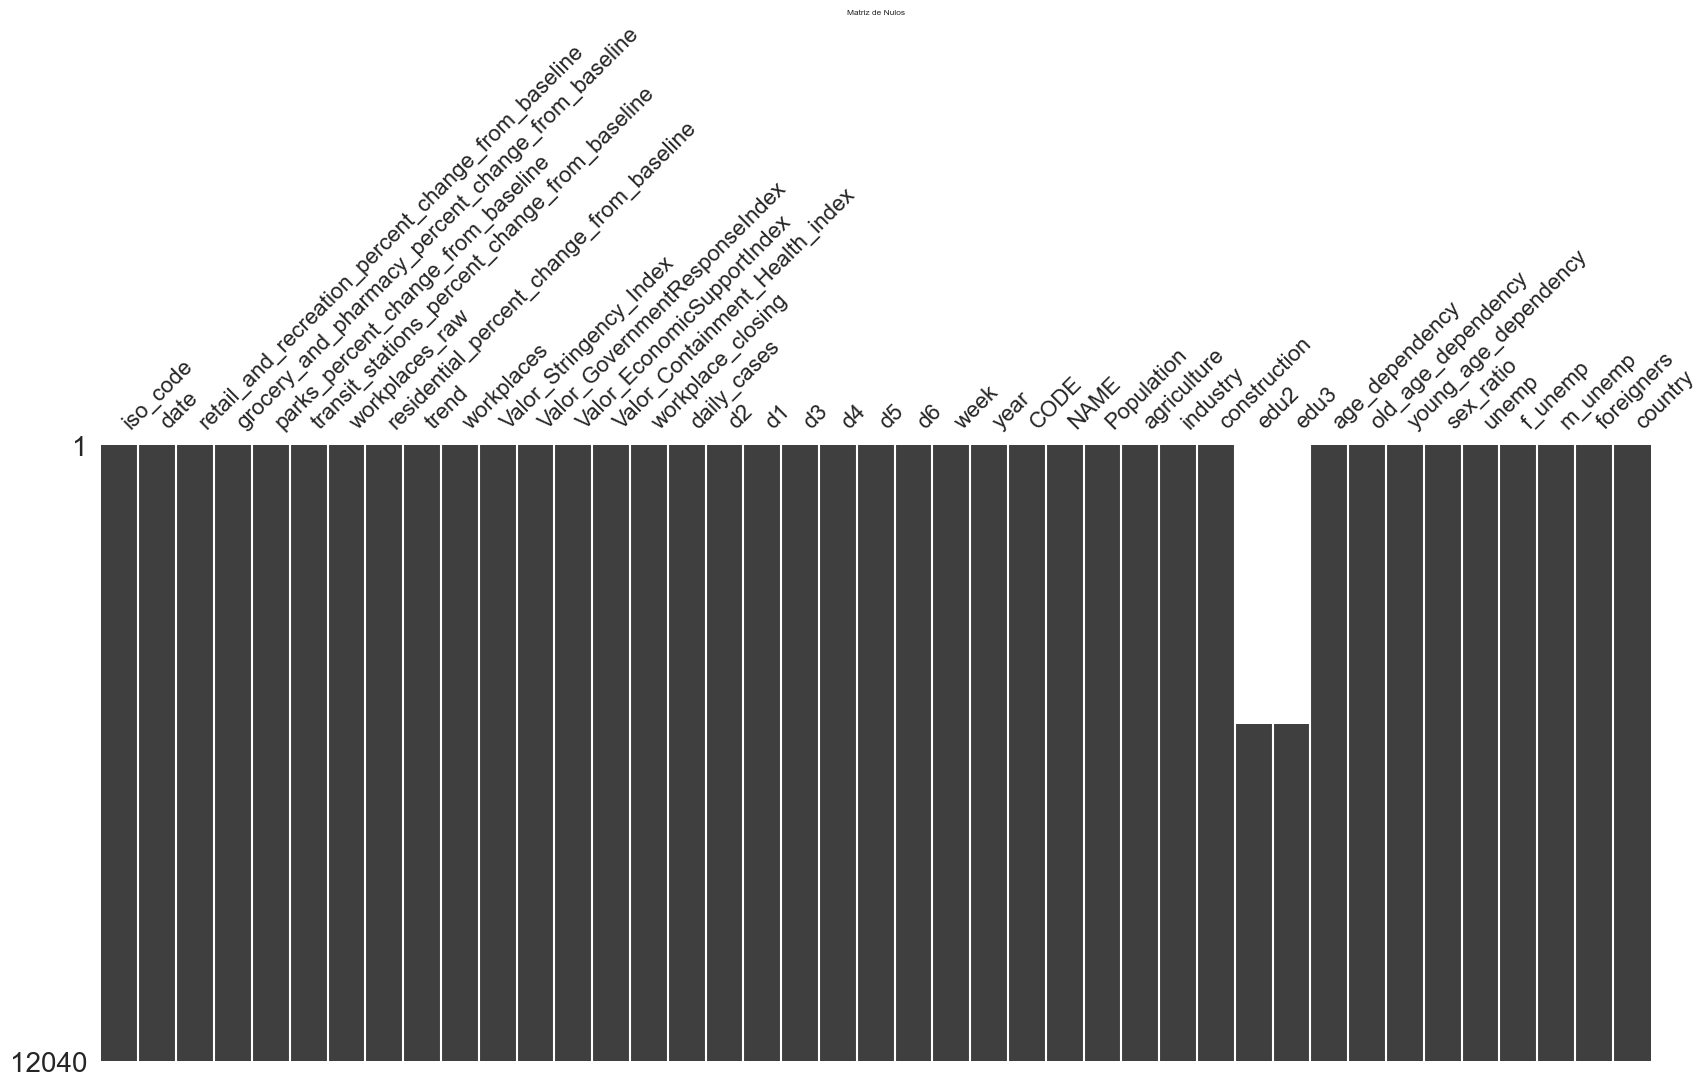

In [186]:
# Cantidad exacta de nulos por variable
#print(df.isnull().sum())

# Visualización de matriz de datos faltantes
plt.figure(figsize=(20, 8))
msn.matrix(df, figsize=(20, 8), sparkline=False)
plt.title('Matriz de Nulos', fontsize=6)
plt.show()

### Distribución de variables numéricas

Generando matriz de histogramas para 30 variables numéricas...


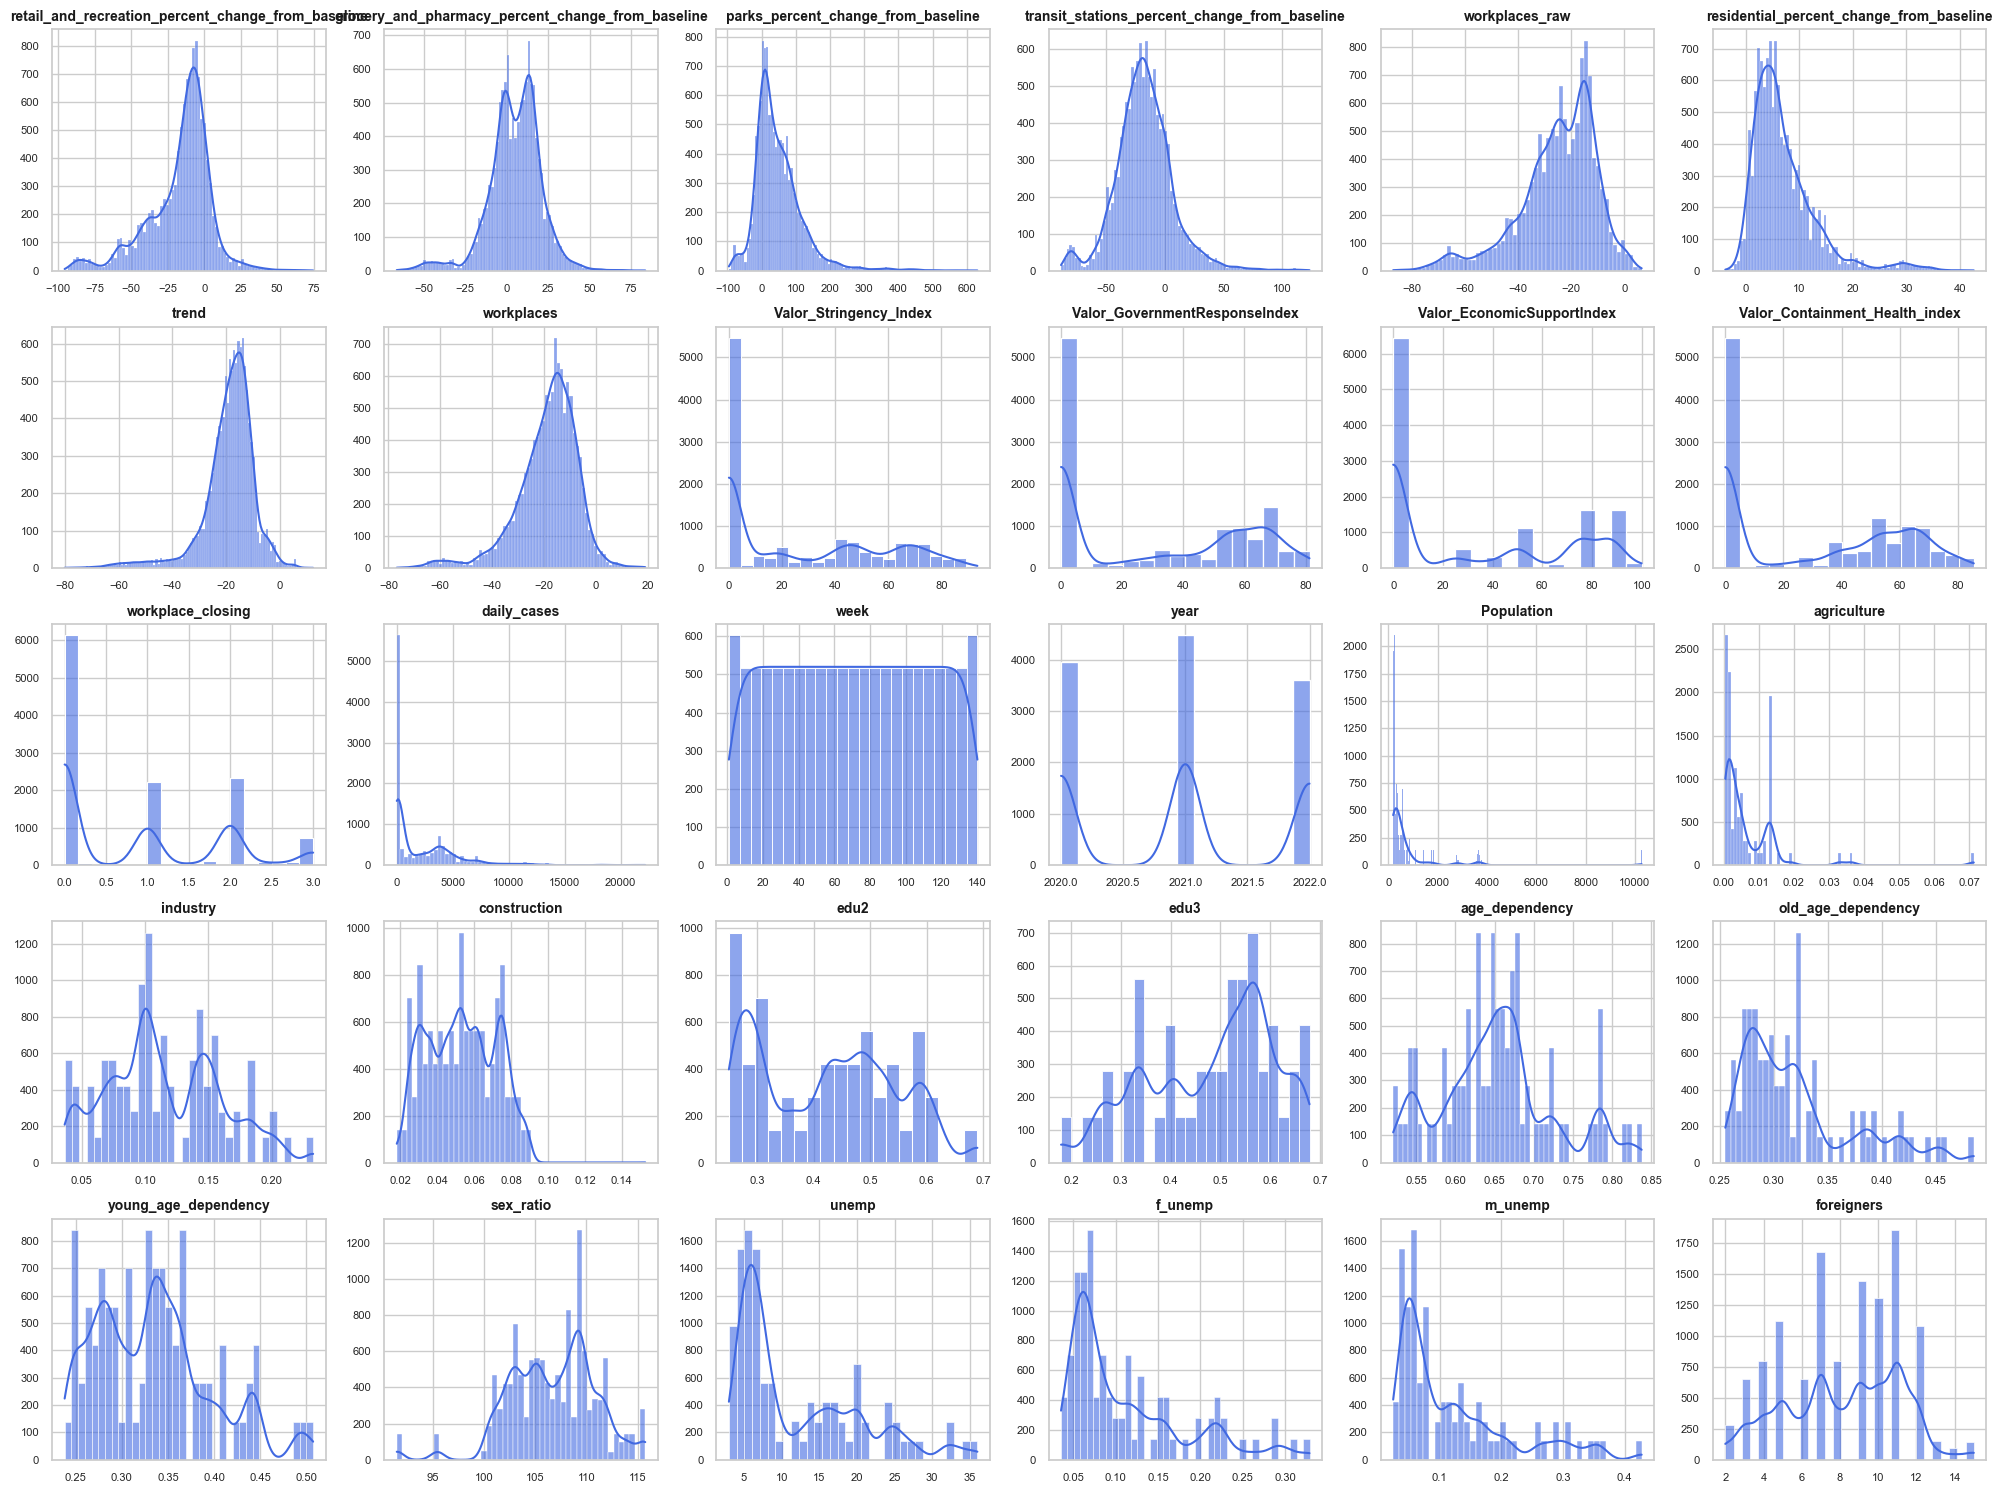

Generando matriz de boxplots para 30 variables numéricas...


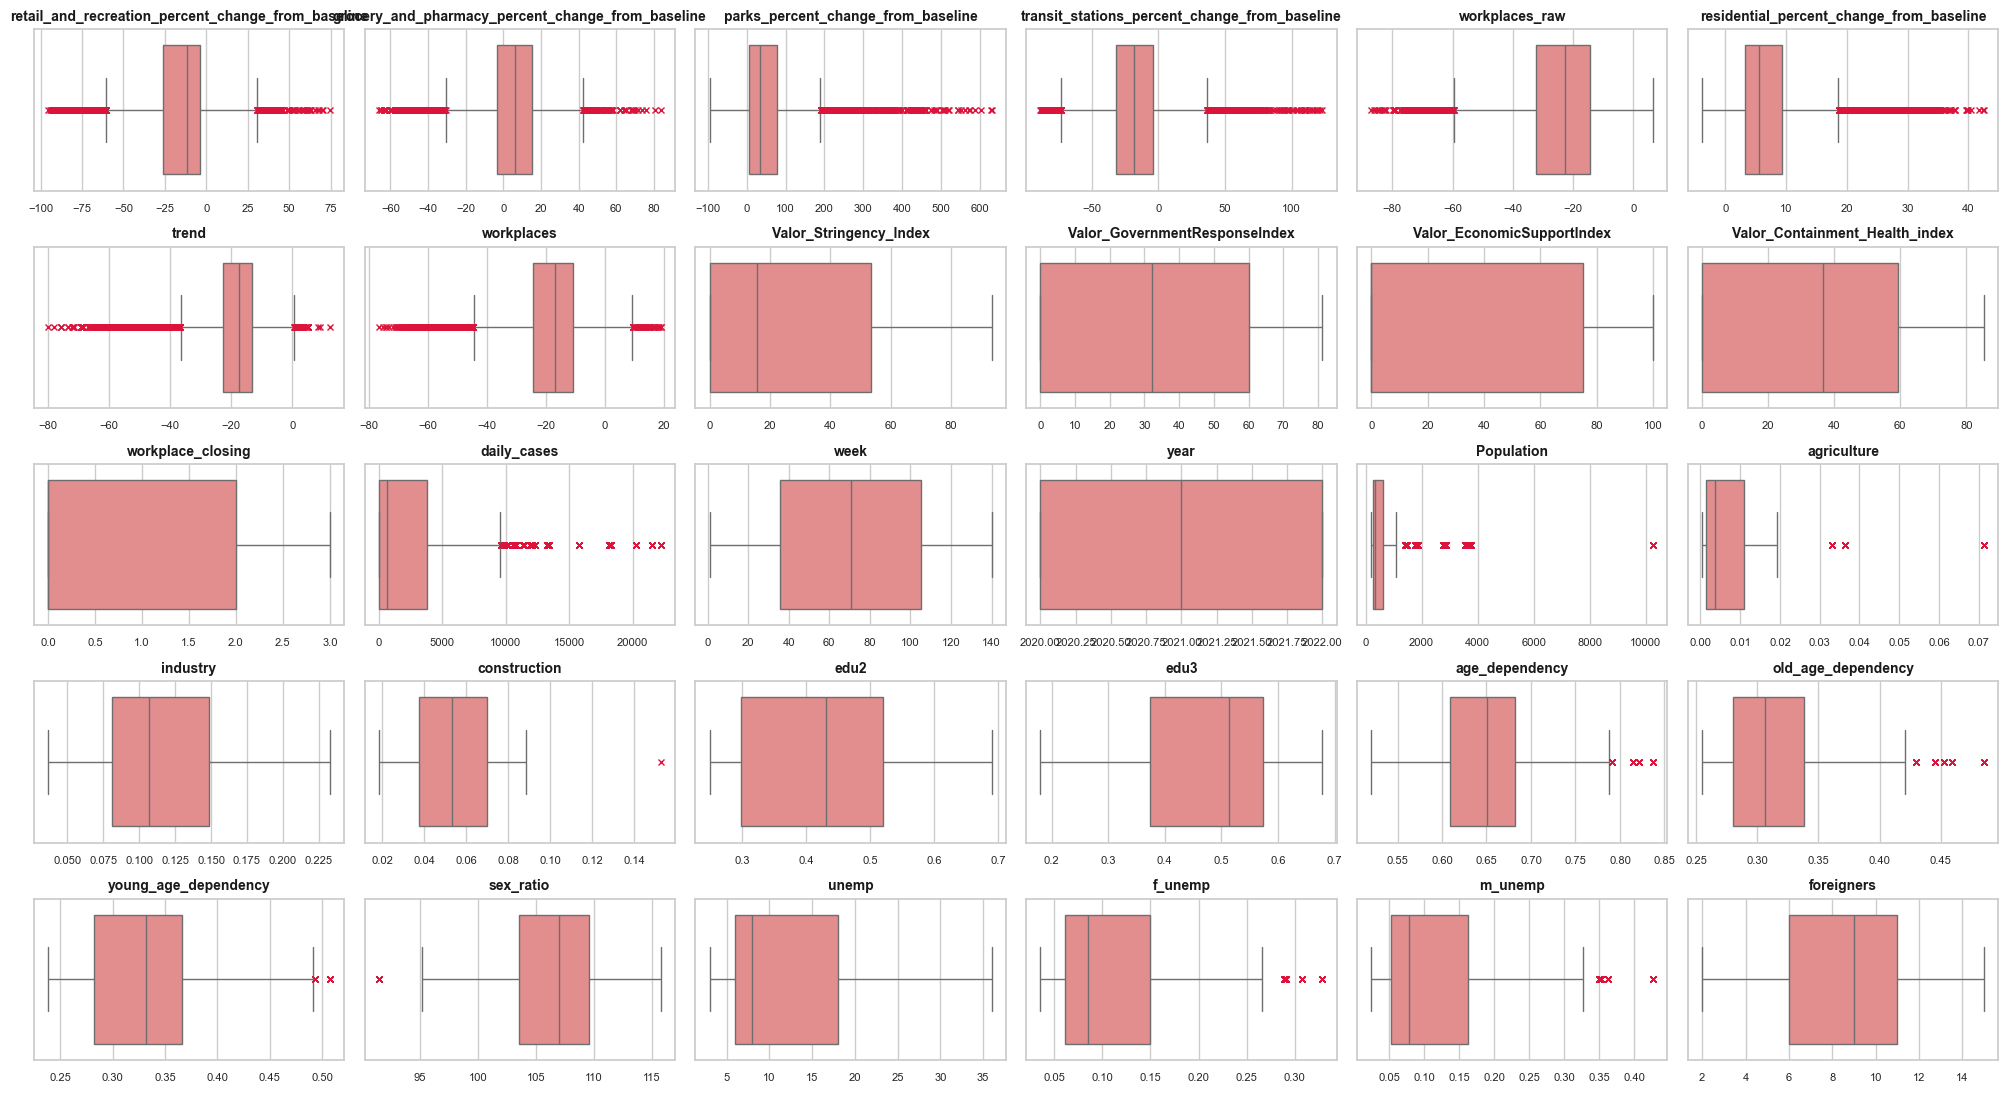

In [187]:
# 1. Configuración de estilo 
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 9
plt.rcParams['figure.figsize'] = (20, 15)

# 2. Seleccionar columnas numéricas del DataFrame
columnas_numericas = df.select_dtypes(include=['number']).columns.tolist()

# Excluir variables binarias de la lista
vars_a_excluir = ['d1', 'd2', 'd3', 'd4', 'd5', 'd6']
columnas_numericas = [col for col in columnas_numericas if col not in vars_a_excluir]
n_vars = len(columnas_numericas)

# Calcular dimensiones de la matriz (para 36 variables, una cuadrícula de 6x6 es perfecta)
n_cols = 6
n_rows = math.ceil(n_vars / n_cols)

# --- FIGURA 1: MATRIZ DE HISTOGRAMAS Y DENSIDADES (KDE) ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows))
axes = axes.flatten()

print(f"Generando matriz de histogramas para {n_vars} variables numéricas...")
for i, var in enumerate(columnas_numericas):
    sns.histplot(
        data=df[df[var].notna()], 
        x=var, 
        kde=True, 
        ax=axes[i], 
        color='royalblue', 
        edgecolor='white', 
        alpha=0.6
    )
    axes[i].set_title(f'{var}', fontsize=10, fontweight='bold', color='#1a1a1a')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='both', which='major', labelsize=8)

# Ocultar subplots vacíos si n_vars no es múltiplo exacto de n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- FIGURA 2: MATRIZ DE BOXPLOTS (DETECCIÓN DE OUTLIERS) ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2.2 * n_rows))
axes = axes.flatten()

print(f"Generando matriz de boxplots para {n_vars} variables numéricas...")
for i, var in enumerate(columnas_numericas):
    sns.boxplot(
        data=df[df[var].notna()], 
        x=var, 
        ax=axes[i], 
        color='lightcoral', 
        flierprops={"marker": "x", "markerfacecolor": "crimson", "markeredgecolor": "crimson", "markersize": 4}
    )
    axes[i].set_title(f'{var}', fontsize=10, fontweight='bold', color='#1a1a1a')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='both', which='major', labelsize=8)

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Análisis sobre Distribuciones y Outliers

Al examinar los histogramas y boxplots de las variables numéricas del panel, se observan valores que caen fuera de los umbrales estándar del criterio de Tukey para deteccion de valores atipicos en variables de movilidad ("workplaces"), indicadores de políticas ("Valor_Stringency_Index") y variables epidemiológicas ("daily_cases").

Se determina no eliminar estos valores extremos por dos razones:
1. Los extremos en movilidad (hasta -76.8% en "workplaces") no son errores de medición, sino eventos históricos reales (confinamientos y olas de contagio). Eliminarlos descartaría los episodios más relevantes del fenómeno estudiado.
2. Eliminar estos picos borraría la variación temporal dentro de cada ciudad que el estimador de efectos fijos necesita para identificar el efecto causal de las restricciones.

### Comportamiento de Variables Categóricas

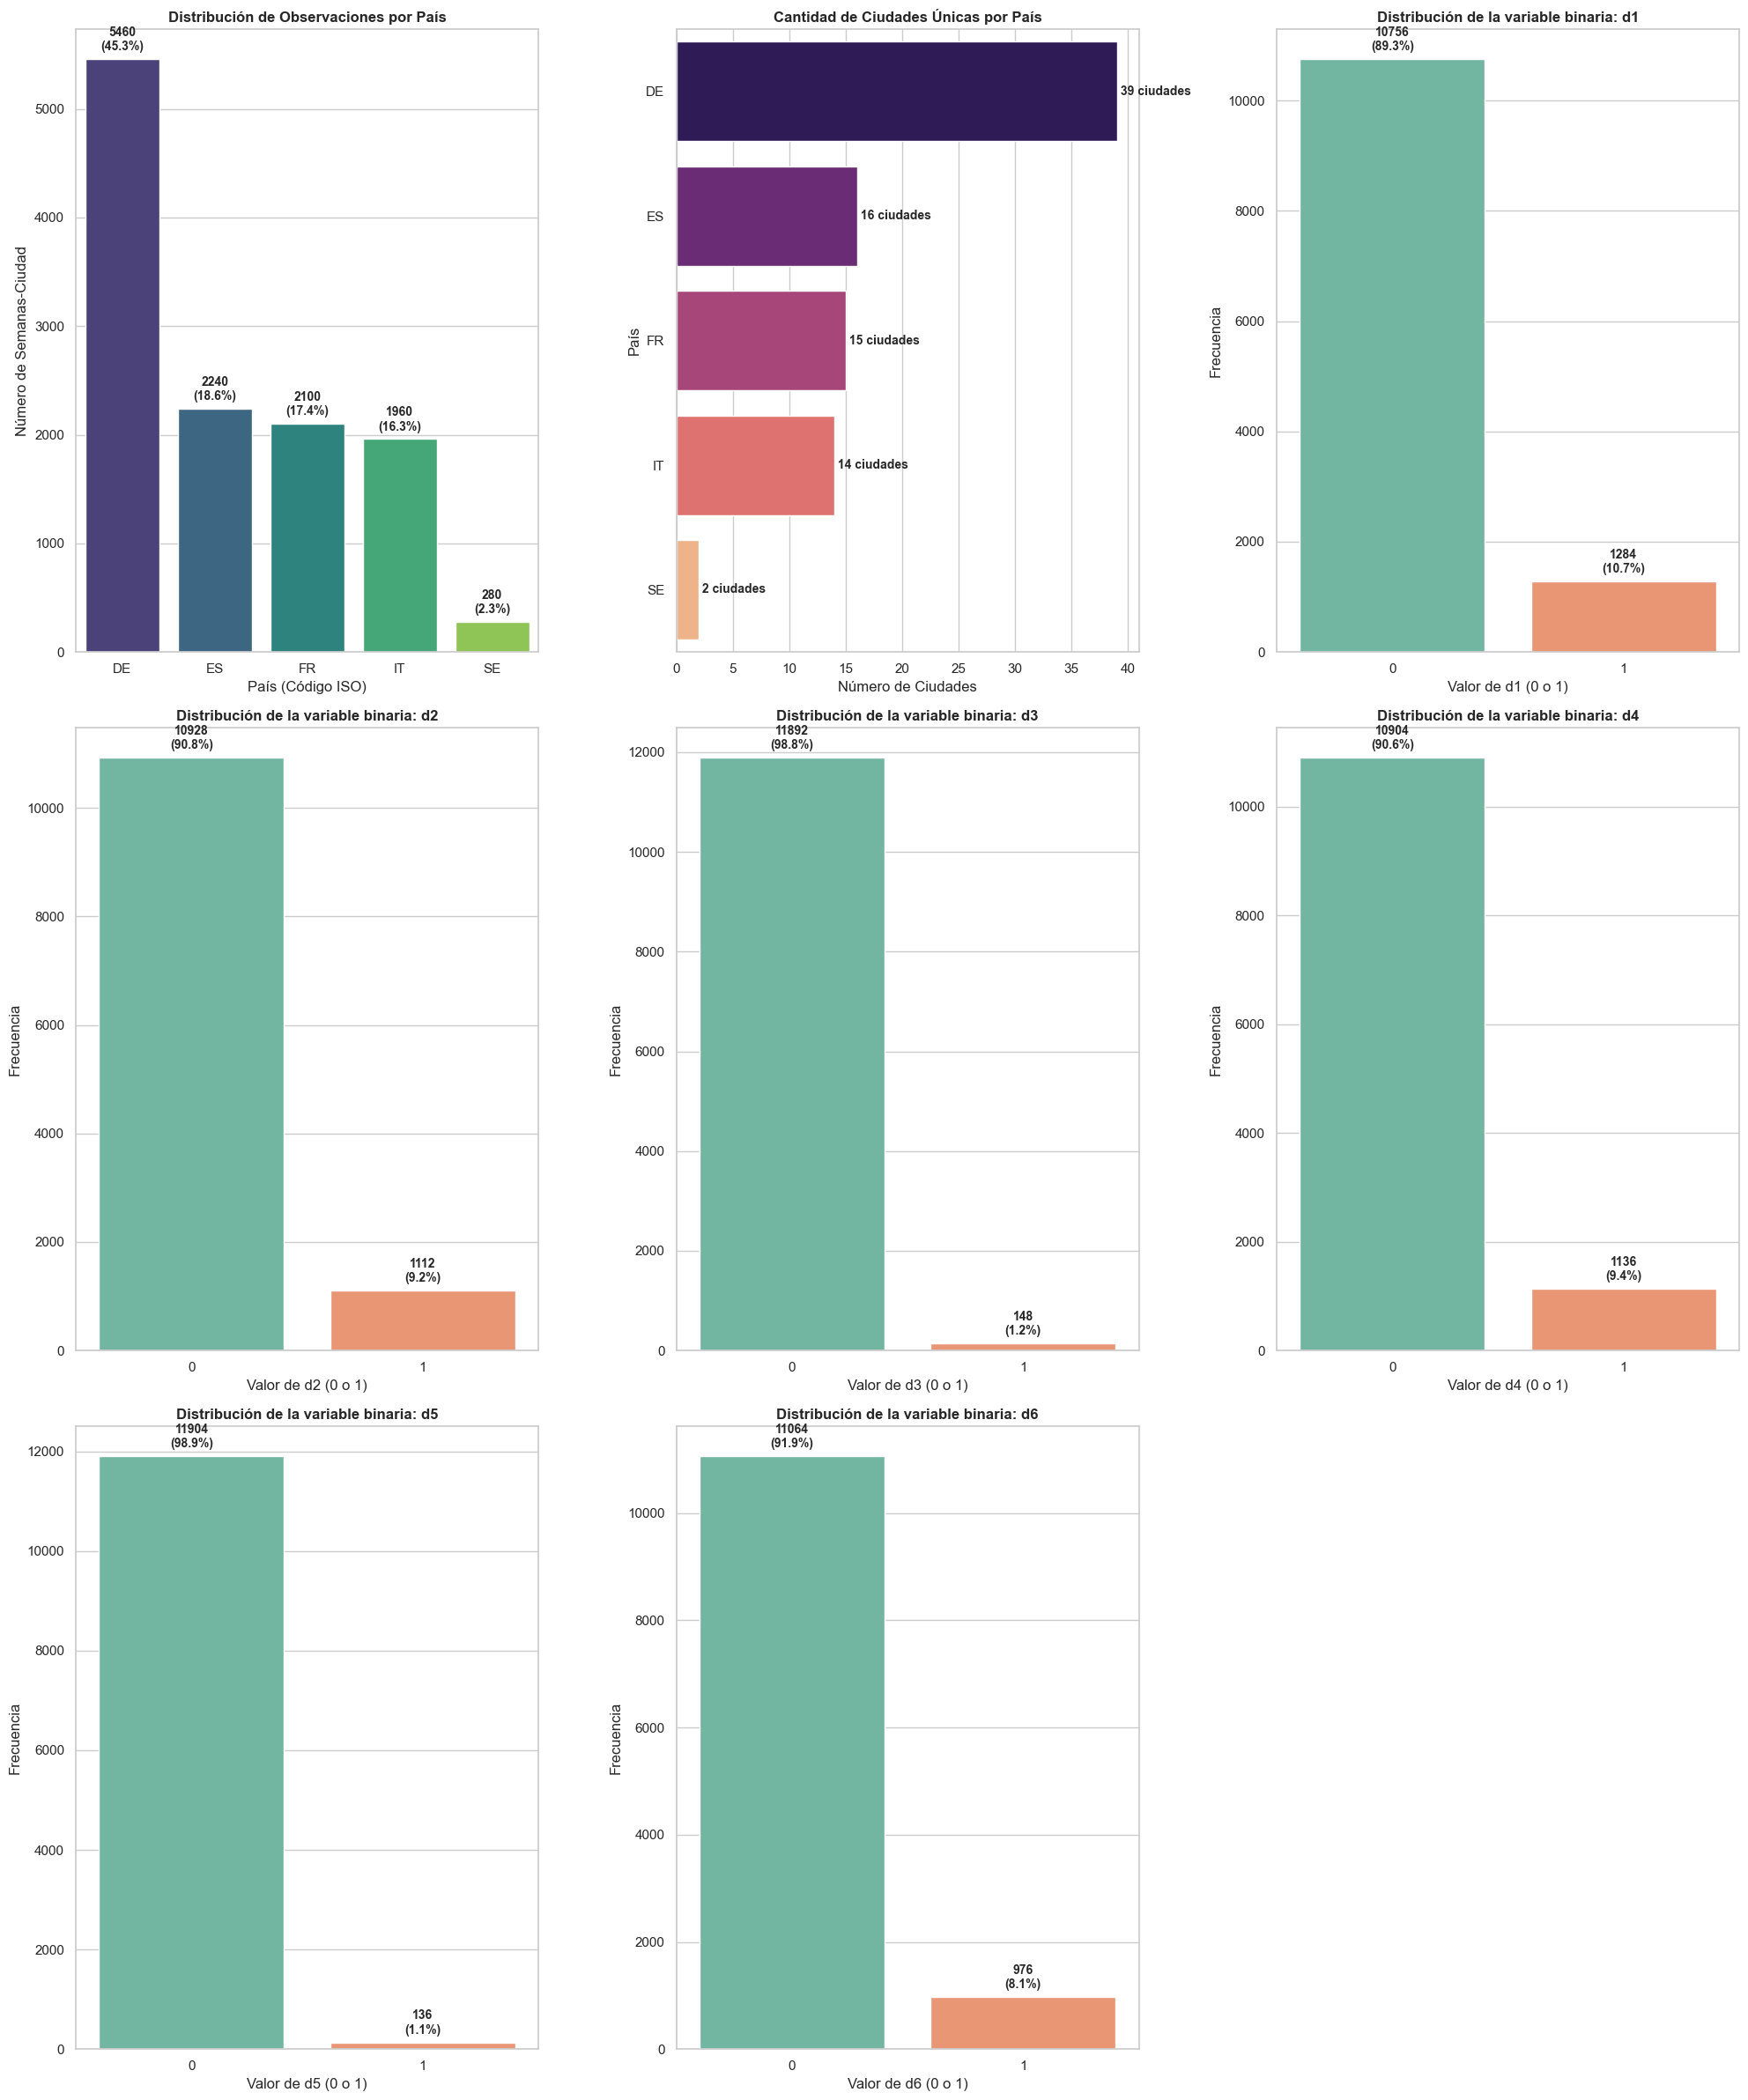

─── Resumen Descriptivo del Panel Categórico ───
Total de observaciones (filas): 12040
Número de Ciudades únicas (N): 86
Número de Semanas por ciudad (T): 140
Variables binarias analizadas individualmente: d1, d2, d3, d4, d5, d6


In [188]:
# 1. Configurar el tema y estilo estético
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (20, 18)

# 2. Identificar variables categóricas (object) en tu DataFrame
variables_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Excluimos 'date' de este análisis si ya fue parseada a datetime
if 'date' in variables_categoricas:
    variables_categoricas.remove('date')

# Añadimos manualmente las variables binarias al análisis
vars_binarias = ['d1', 'd2', 'd3', 'd4', 'd5', 'd6']
vars_binarias = [v for v in vars_binarias if v in df.columns]
variables_categoricas.extend(vars_binarias)

# 3. Crear figura con subplots
# Usaremos una cuadrícula de 3x3 para acomodar los gráficos de país y las 6 variables binarias
fig, axes = plt.subplots(3, 3, figsize=(20, 24))
axes = axes.flatten()

# --- GRÁFICO 1: Frecuencia de Observaciones por País ---
if 'country' in df.columns:
    order_country = df['country'].value_counts().index
    ax1 = sns.countplot(
        data=df, 
        x='country', 
        order=order_country, 
        ax=axes[0], 
        palette='viridis'
    )
    total_obs = len(df)
    for p in ax1.patches:
        height = p.get_height()
        percentage = (height / total_obs) * 100
        ax1.annotate(
            f'{int(height)}\n({percentage:.1f}%)', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            fontweight='bold',
            xytext=(0, 5), 
            textcoords='offset points'
        )
    axes[0].set_title('Distribución de Observaciones por País', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('País (Código ISO)')
    axes[0].set_ylabel('Número de Semanas-Ciudad')

# --- GRÁFICO 2: Ciudades Únicas por País ---
if 'NAME' in df.columns and 'country' in df.columns:
    ciudades_por_pais = df.groupby('country')['NAME'].nunique().reset_index()
    ciudades_por_pais = ciudades_por_pais.sort_values(by='NAME', ascending=False)
    
    ax2 = sns.barplot(
        data=ciudades_por_pais, 
        y='country', 
        x='NAME', 
        ax=axes[1], 
        palette='magma', 
        orient='h'
    )
    for p in ax2.patches:
        width = p.get_width()
        ax2.annotate(
            f' {int(width)} ciudades', 
            (width, p.get_y() + p.get_height() / 2.), 
            ha='left', 
            va='center', 
            fontsize=10, 
            fontweight='bold'
        )
    axes[1].set_title('Cantidad de Ciudades Únicas por País', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Número de Ciudades')
    axes[1].set_ylabel('País')

# --- GRÁFICOS 3 al 8: Un gráfico para cada variable binaria (d1-d6) ---
for i, var in enumerate(vars_binarias):
    ax_bin = axes[i + 2] # Empezamos a llenar desde el índice 2 de la matriz
    sns.countplot(
        data=df, 
        x=var, 
        ax=ax_bin, 
        palette='Set2'
    )
    
    total_var_obs = len(df[var].dropna())
    if total_var_obs > 0:
        for p in ax_bin.patches:
            height = p.get_height()
            percentage = (height / total_var_obs) * 100
            ax_bin.annotate(
                f'{int(height)}\n({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', 
                va='bottom', 
                fontsize=10, 
                fontweight='bold',
                xytext=(0, 5), 
                textcoords='offset points'
            )
            
    ax_bin.set_title(f'Distribución de la variable binaria: {var}', fontsize=12, fontweight='bold')
    ax_bin.set_xlabel(f'Valor de {var} (0 o 1)')
    ax_bin.set_ylabel('Frecuencia')

# Ocultar los subplots vacíos (en la grilla 3x3 sobran espacios si hay menos de 7 gráficos totales, en este caso 8 gráficos, sobra 1)
for j in range(len(vars_binarias) + 2, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 4. Mostrar resumen impreso del panel
print("─── Resumen Descriptivo del Panel Categórico ───")
print(f"Total de observaciones (filas): {len(df)}")
if 'NAME' in df.columns:
    print(f"Número de Ciudades únicas (N): {df['NAME'].nunique()}")
if 'week' in df.columns:
    print(f"Número de Semanas por ciudad (T): {df.groupby('NAME')['week'].nunique().max()}")
print(f"Variables binarias analizadas individualmente: {', '.join(vars_binarias)}")


### Análisis de datos faltantes: "edu2" y "edu3"
Alemania (DE) no reporta datos para "edu2" y "edu3" (5,460 nulos = 39 ciudades x 140 semanas). Incluir estas variables forzaría la eliminación de Alemania del panel, perdiendo aproximadamente el 45% de la muestra.

Dado que la educación es invariante en el tiempo para cada ciudad en este dataset, el estimador FE la absorbería de todos modos, eliminandola. Se excluyen "edu2" y "edu3" para conservar la integridad del panel.

In [189]:
print("Nulos en 'edu2' por País:")
print(df.groupby('country')['edu2'].apply(lambda x: x.isna().sum()))
print(df.groupby('country')['edu3'].apply(lambda x: x.isna().sum()))

print("\nTotal de observaciones por País:")
print(df['country'].value_counts())


Nulos en 'edu2' por País:
country
DE    5460
ES       0
FR       0
IT       0
SE       0
Name: edu2, dtype: int64
country
DE    5460
ES       0
FR       0
IT       0
SE       0
Name: edu3, dtype: int64

Total de observaciones por País:
country
DE    5460
ES    2240
FR    2100
IT    1960
SE     280
Name: count, dtype: int64


### Distribución de variables clave y escalamiento

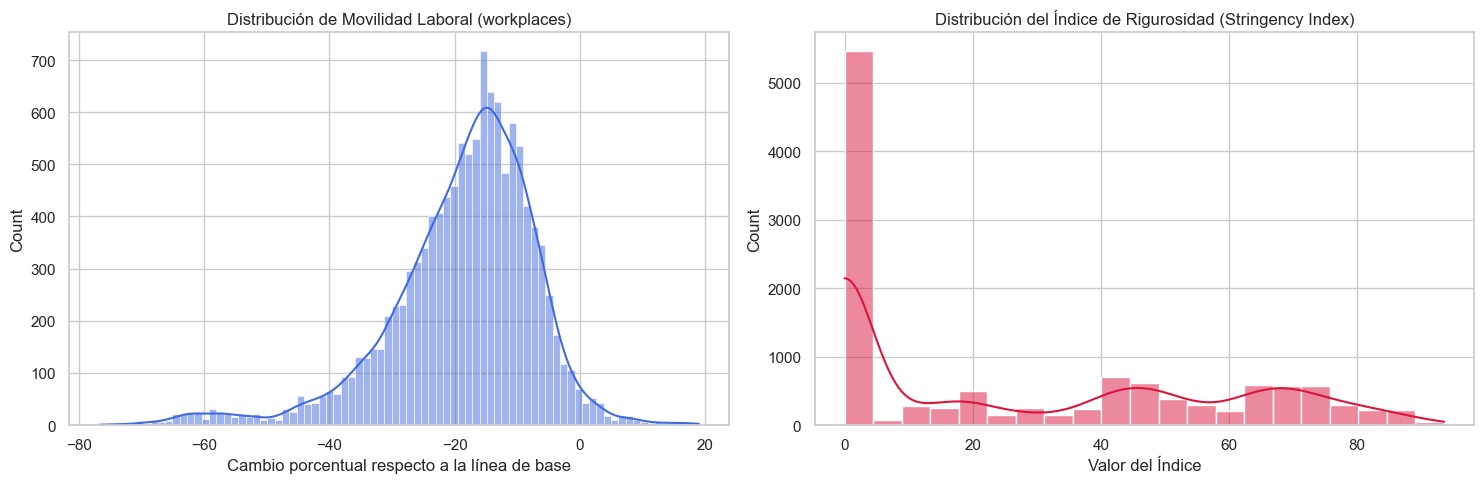

Nulos en workplaces: 0
Nulos en Valor_Stringency_Index: 0


In [190]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['workplaces'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribución de Movilidad Laboral (workplaces)')
axes[0].set_xlabel('Cambio porcentual respecto a la línea de base')

sns.histplot(df['Valor_Stringency_Index'], kde=True, ax=axes[1], color='crimson')
axes[1].set_title('Distribución del Índice de Rigurosidad (Stringency Index)')
axes[1].set_xlabel('Valor del Índice')

plt.tight_layout()
plt.show()

print("Nulos en workplaces:", df['workplaces'].isna().sum())
print("Nulos en Valor_Stringency_Index:", df['Valor_Stringency_Index'].isna().sum())

"workplaces" muestra una distribución con asimetria negativa (períodos de confinamiento), mientras que "Valor_Stringency_Index" concentra valores en 0 (pre-pandemia) y en niveles altos (cuarentenas). Ambas variables no presentan nulos.

Se escalan dos variables para un mejor manejo e interpretacion:
- "daily_cases_10k": Casos diarios / 10,000
- "Population_100k": Población / 100

In [191]:
# Escalar variables
df['daily_cases_10k'] = df['daily_cases'] / 10000.0
df['Population_100k'] = df['Population'] / 100.0


### Correlaciones (Mapa de calor)

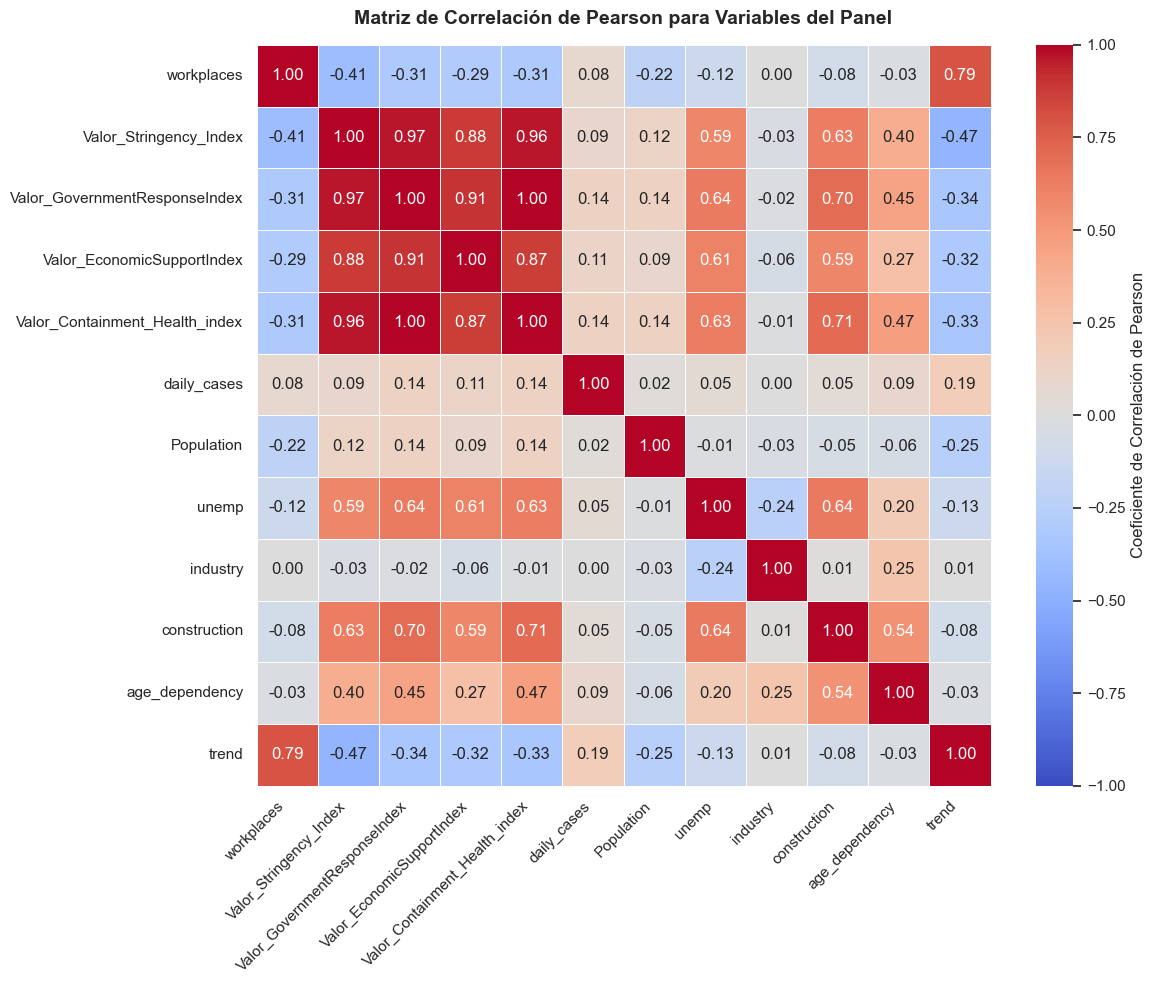

In [192]:
# 1. Seleccionar variables numéricas clave para el análisis de correlación
columnas_interes = ['workplaces', 'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex', 
                    'Valor_EconomicSupportIndex', 'Valor_Containment_Health_index', 
                    'daily_cases', 'Population', 'unemp', 'industry', 'construction', 'age_dependency',"trend"]

matriz_correlacion = df[columnas_interes].corr()

# 2. Graficar el Heatmap de correlación lineal de Pearson
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_correlacion, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1,
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)
plt.title('Matriz de Correlación de Pearson para Variables del Panel', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


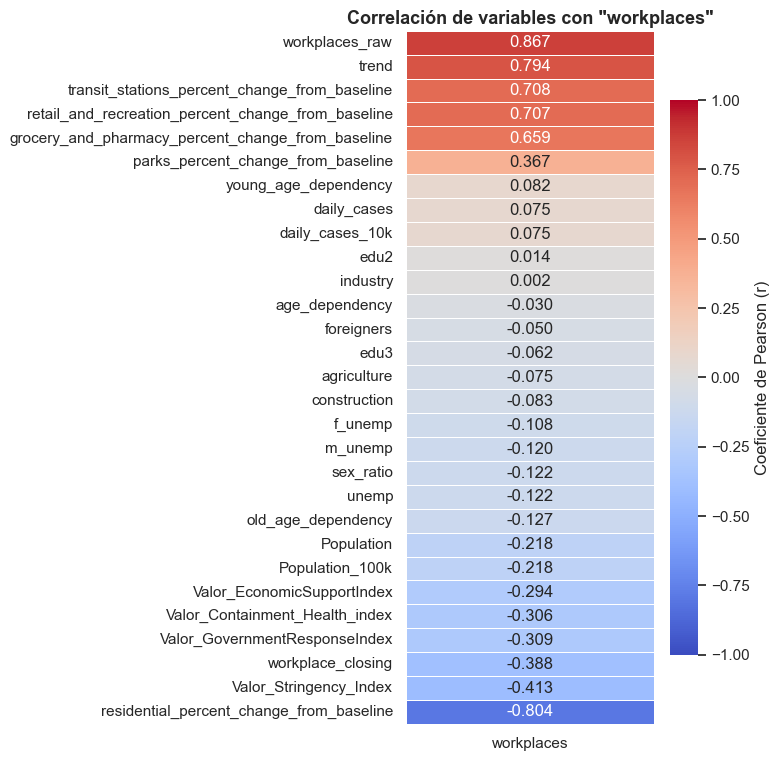

In [210]:
# 1. Configuración de estilo visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (4, 9) # Formato vertical (alto)

# 2. Seleccionar columnas numéricas (float64) y calcular matriz general
columnas_float = df.select_dtypes(include=['float64']).columns.tolist()
matriz_correlacion = df[columnas_float].corr()

# Extraer solo la columna de 'workplaces' como DataFrame bidimensional y ordenarla
correlacion_workplaces = matriz_correlacion[['workplaces']].drop('workplaces', errors='ignore').sort_values(by='workplaces', ascending=False)

# 3. Heatmap Enfocado (estilo Tarea 1, en filas)
plt.figure(figsize=(4, 9))
sns.heatmap(
    correlacion_workplaces, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".3f", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson (r)'}
)

plt.title('Correlación de variables con "workplaces"', fontsize=13, fontweight='bold', pad=5)
plt.xlabel('')

plt.tight_layout()
plt.show()


### Análisis de multicolinealidad y selección de variables para los modelos

Para garantizar la validez de las estimaciones y evitar problemas de multicolinealidad severa que puedan inflar los errores estándar y sesgar los coeficientes, realizamos un análisis de correlación lineal de Pearson entre las variables continuas clave:

1. Colinealidad entre índices gubernamentales: Observamos que el "Valor_Stringency_Index", "Valor_GovernmentResponseIndex" y "Valor_Containment_Health_index" tienen una correlación lineal de 0.98 a 0.99 (casi perfecta). Incluir más de uno de estos índices en el modelo resultaría en estimaciones altamente inestables e inconsistentes. Por lo tanto, seleccionamos únicamente "Valor_Stringency_Index" como nuestro regresor de interés principal, ya que es el indicador más ampliamente utilizado en la literatura para capturar la rigurosidad de las políticas.
2. Se excluyen variables como "residential_percent_change_from_baseline" y "parks_percent_change_from_baseline" ya que estas son variables de respuesta que resultan afectadas simultáneamente por la variable de tratamiento.
3. Correlaciones de control y relación de movilidad: La movilidad laboral ("workplaces") muestra una fuerte correlación negativa esperada con el índice de rigurosidad (-0.58), lo que es consistente con la teoría.
4. Se define la variable dependiente "workplaces": Esta variable mide la variación porcentual de la movilidad física de las personas hacia sus oficinas en comparación con el baseline prepandemia, se optó por esta y no "workplaces_raw" ya que esta tiene caidas producidas por feriados, que no guardan relación con las restricciones del gobierno.
5. Selección Final de Variables: Con base en este análisis y en la estructura categórica (resumida anteriormente), incluimos en el modelo final:
   - Variable dependiente (Y): "workplaces".
   - Regresor de interés: "Valor_Stringency_Index".
   - Controles continuos escalados: "daily_cases_10k" y "Population_100k".
   - Controles laborales y demográficos: "unemp" (desempleo), "industry" (proporción de empleo industrial), "construction" (proporción de empleo en construcción) y la variable de tendencia temporal "trend" para capturar la evolución de la pandemia.

## Pregunta 2: Modelo Pooled OLS (MCO Agrupado)

El modelo Pooled OLS trata el panel como una gran base de corte transversal, asumiendo errores i.i.d. e ignorando la heterogeneidad individual inobservada.

In [211]:
# Definir MultiIndex para el panel
df_panel = df.set_index(['NAME', 'week'])

y = df_panel['workplaces']
X = df_panel[['Valor_Stringency_Index', 'daily_cases_10k', 'Population_100k', 'unemp', 'industry', 'construction', 'trend']]
X = sm.add_constant(X)

# Ajustar Pooled OLS
pooled_mod = lmp.PooledOLS(y, X)
pooled_res = pooled_mod.fit(cov_type='robust')
print(pooled_res)

                          PooledOLS Estimation Summary                          
Dep. Variable:             workplaces   R-squared:                        0.6374
Estimator:                  PooledOLS   R-squared (Between):              0.9910
No. Observations:               12040   R-squared (Within):               0.5793
Date:                Mon, May 25 2026   R-squared (Overall):              0.6374
Time:                        04:42:42   Log-likelihood                -4.069e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      3021.9
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,12032)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             3663.5
                            

### Interpretacion
El modelo final a estimar queda parametrizado bajo la siguiente especificación lineal:

$$\text{workplaces}_{it} = \beta_0 + \beta_1 \text{Valor\_Stringency\_Index}_{it} + \beta_2 \text{daily\_cases\_10k}_{it} + \\
\beta_3 \text{Population\_100k}_{i} + \beta_4 \text{unemp}_{i} + \beta_5 \text{industry}_{i} + \beta_6 \text{construction}_{i} + \beta_7 \text{trend}_{t} + u_{it}$$

Donde:
* $i$ denota la ciudad ($NAME$) y $t$ la semana temporal ($week$).
* $\beta_1$ es el estimador de interés que mide el impacto de las restricciones sobre la movilidad laboral.
* $\beta_2, \dots, \beta_7$ corresponden a los coeficientes de los controles teóricos seleccionados para aislar el sesgo de estimación.

| Variable | Coef. | Interpretación (ceteris paribus) |
|----------|-------|----------------------------------|
| "Valor_Stringency_Index" | -0.0216 | +1 punto en restricciones reduce movilidad en 0.0216 pp |
| "daily_cases_10k" | -2.4527 | +10,000 casos reduce movilidad en 2.45 pp, demostrando la preocupacion y autocuidado |
| "construction" | +11.841 | Sector con presencia de trabajo presencial rígido asociado a mayor movilidad |
| "trend" | +0.9330 | Retorno de ~0.93 pp por semana (normalización) |
| "Population_100k" | -0.0102 | Significativo al 10%, sugiere que ciudades mas grandes tuvieron una menor reduccion de movilidad |
| "unemp" | -0.0015 | No significativo |
| "industry" | -1.5241 | No significativo|

El modelo se ejecuta sobre un panel de datos balanceado perfecto de 12,040 observaciones ($N = 86$ ciudades seguidas durante $T = 140$ semanas).
Se utilizó un estimador de covarianza robusto. Esto es metodológicamente correcto para controlar la heterocedasticidad y la autocorrelación serial dentro de los residuos del panel.
Bondad de ajuste: El $R^2$ global es de 0.6374 . Esto significa que las variables independientes seleccionadas (restricciones, casos, demografía, empleo y tiempo) explican un 63.74% toda la variabilidad de la movilidad al trabajo en Europa durante la pandemia.
$R^2$ Between vs. $R^2$ Within: El $R^2$ Between es alto ($0.9910$), lo que indica que nuestro modelo explica casi la totalidad de las diferencias de movilidad entre las distintas ciudades. El $R^2$ Within es de $0.5793$, capturando la variación temporal interna de cada ciudad a lo largo de las semanas.
El estadístico $F$ robusto es de $3663.5$ con un p-value = 0.0000, rechazando la hipótesis nula de que todos los coeficientes son iguales a cero.


## Pregunta 3: Modelo de efectos fijos (FE)

El estimador de Efectos Fijos (FE) controla por toda la heterogeneidad inobservada invariante en el tiempo para cada unidad (ciudad). De este modo, remueve el sesgo por variables omitidas invariantes en el tiempo realizando una transformación de desviaciones respecto a la media de cada entidad.


In [212]:
# Ajustar Modelo de Efectos Fijos
fe_mod = lmp.PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
fe_res = fe_mod.fit(cov_type='robust')
print(fe_res)


                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.5796
Estimator:                   PanelOLS   R-squared (Between):             -16.511
No. Observations:               12040   R-squared (Within):               0.5796
Date:                Mon, May 25 2026   R-squared (Overall):             -1.8324
Time:                        05:08:33   Log-likelihood                -4.067e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2352.9
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,11947)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             3150.9
                            

### Interpretación del modelo de efectos fijos

Resultados :$R^2$ Within = 0.5796, $R^2$ Between negativo ya que el estimador de efectos fijos se diseña única y exclusivamente para minimizar la varianza temporal dentro de las unidades, descartando la varianza de sección cruzada.

| Variable | Coef. | Interpretación (ceteris paribus) |
|----------|-------|----------------------------------|
| "Valor_Stringency_Index" | -0.0338 | +1 punto en restricciones reduce movilidad en 0.0338 pp |
| "daily_cases_10k2 | -2.3730 | +10,000 casos reduce movilidad en 2.37 pp |
| "trend" | +0.9125 | Retorno de ~0.91 pp por semana |
| "unemp" | +0.5733 | +1 punto de desempleo aumenta la movilidad en 0.5733 pp |
| "Population_100k" | +1.3658 | No significativo|
| "industry" | -63.084 | No significativo |
| "construction" | -8.8706 | No significativo |

 El coeficiente de "Valor_Stringency_Index" pasa de -0.0216 (Pooled) a -0.0338 (FE), un 56% más negativo en magnitud. Esto revela que MCO agrupado sufría de sesgo por por variable omitida: al no controlar por características fijas de cada ciudad (geografía, cultura de teletrabajo, densidad), subestimaba la efectividad real de las restricciones.

 Algo curioso es como el desempleo logra aumentar la movilidad, explicado quizas por que a mayor desempleo, la gente se ve obligada a salir a la calle a buscar ingresos informales o empleo, rompiendo asi la cuarentena.

El $R^2$ Between negativo (-16.511) es normal en FE: la transformación Within descarta la varianza de sección cruzada, que es absorbida completamente por los efectos fijos individuales.

Las variables estructurales ("industry", "construction", "Population_100k") son temporalmente casi constantes, por lo que el estimador FE no tiene suficiente variación para estimarlas de forma estable.

## Pregunta 4: Modelo de efectos aleatorios (RE)

El modelo RE asume que la heterogeneidad inobservada de cada ciudad no está correlacionada con las variables explicativas. Si el supuesto se cumple, RE es más eficiente que FE y permite estimar variables invariantes en el tiempo.

In [213]:
# Ajustar Modelo de Efectos Aleatorios
re_mod = lmp.RandomEffects(y, X)
re_res = re_mod.fit(cov_type='robust')
print(re_res)


                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.6374
Estimator:              RandomEffects   R-squared (Between):              0.9910
No. Observations:               12040   R-squared (Within):               0.5793
Date:                Mon, May 25 2026   R-squared (Overall):              0.6374
Time:                        16:51:28   Log-likelihood                -4.069e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      3021.9
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,12032)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             3663.5
                            

### Interpretación del modelo de efectos aleatorios

Los coeficientes de RE son exactamente iguales a los de Pooled OLS. Esto no es un error, es un fenómeno de econometría de panel.

El estimador RE es un GLS (mínimos cuadrados generalizados) que aplica la transformación $X_{it}^* = X_{it} - \theta \bar{X}_i$, donde:

$$\theta = 1 - \sqrt{\frac{\sigma_\epsilon^2}{\sigma_\epsilon^2 + T \sigma_\alpha^2}}$$

En nuestra estimación, la varianza del componente inobservado individual ($\sigma_\alpha^2$) se estima en cero, porque los controles estructurales incluidos ("unemp", "industry", "construction", "Population_100k") absorben tan completamente la varianza "between" que no queda varianza residual inobservada de grupo. Al ser $\sigma_\alpha^2 = 0$, entonces $\theta = 0$ y la transformación GLS no altera los datos, haciendo que RE converja a Pooled OLS.

La interpretación de coeficientes es idéntica a la realizada en la pregunta 2. Sin embargo, la gran discrepancia con FE ($-0.0338$ vs $-0.0216$) sugiere que el supuesto de ortogonalidad de RE es violado, lo que formalizaremos con el Test de Hausman.

## Pregunta 5: Comparación y discusión de modelos (MCO, FE, RE)

A continuación, compararemos los resultados obtenidos en los tres modelos anteriores y realizaremos el Test de Hausman para contrastar la especificación de Efectos Aleatorios frente a la de Efectos Fijos.


In [214]:
# Comparar los tres modelos en una sola tabla
print("─── Comparación de Modelos Panel ───")
print(lmp.compare({'Pooled OLS': pooled_res, 'Fixed Effects': fe_res, 'Random Effects': re_res}))

# Test de Hausman formal
def hausman(fe, re):
    diff = fe.params - re.params
    # Filtramos solo los coeficientes que se estiman en ambos modelos (excluyendo constantes u omitidos)
    common_idx = diff.dropna().index
    diff = diff[common_idx]
    psi = fe.cov.loc[common_idx, common_idx] - re.cov.loc[common_idx, common_idx]
    dof = diff.size - 1
    W = diff.dot(la.inv(psi)).dot(diff)
    pval = stats.chi2.sf(W, dof)
    return W, dof, pval

try:
    W, dof, pval = hausman(fe_res, re_res)
    print(f"\n─── Test de Hausman Formal ───")
    print(f"Estadístico Chi-2: {W:.4f}")
    print(f"Grados de libertad (df): {dof}")
    print(f"P-valor: {pval:.4f}")
except Exception as e:
    print("\nError al calcular el Test de Hausman:", e)


─── Comparación de Modelos Panel ───
                             Model Comparison                             
                               Pooled OLS  Fixed Effects    Random Effects
--------------------------------------------------------------------------
Dep. Variable                  workplaces     workplaces        workplaces
Estimator                       PooledOLS       PanelOLS     RandomEffects
No. Observations                    12040          12040             12040
Cov. Est.                          Robust         Robust            Robust
R-squared                          0.6374         0.5796            0.6374
R-Squared (Within)                 0.5793         0.5796            0.5793
R-Squared (Between)                0.9910        -16.511            0.9910
R-Squared (Overall)                0.6374        -1.8324            0.6374
F-statistic                        3021.9         2352.9            3021.9
P-value (F-stat)                   0.0000         0.0000       

### Resultados

Diferencias entre los modelos:

1. Pooled OLS y RE son idénticos (por el colapso de $\theta = 0$ explicado anteriormente).
2. FE difiere sustancialmente: el coeficiente del Stringency Index pasa de -0.0216 a -0.0338 (56% más negativo).

La diferencia se debe al sesgo por heterogeneidad no observada. Pooled OLS/RE asumen que características fijas no observables de las ciudades (cultura de teletrabajo, geografía, densidad de transporte publico, etc) no se correlacionan con las restricciones gubernamentales. En la práctica, los gobiernos aplican restricciones más severas en ciudades densas con dinámicas de contagio complejas, que también tienen comportamientos de movilidad laboral diferentes. Al no controlar por esto, Pooled/RE subestiman el verdadero efecto de las restricciones. FE limpia este sesgo mediante la transformación Within.

Test de Hausman:

$$\chi^2 = 97.89 \quad (\text{df} = 7) \quad \Rightarrow \quad p = 0.0000$$

Se rechaza $H_0$ (efectos individuales no correlacionados con regresores). El estimador RE es inconsistente. El modelo adecuado es Efectos Fijos (FE).


El modelo de Efectos Fijos es el más adecuado para responder la pregunta de investigación, ya que garantiza consistencia ante la presencia de heterogeneidad inobservada correlacionada con los regresores (ratificado por Hausman). Su limitación es la inutilización de variables estructurales casi constantes en el tiempo.

Variables robustas a la especificación:

Tres variables mantienen alta significancia, signo consistente y magnitudes estables en los tres modelos:
1. "Valor_Stringency_Index" ($-0.0216$ a $-0.0338$): Las restricciones siempre reducen la movilidad laboral.
2. "daily_cases_10k" ($-2.37$ a $-2.45$): El canal de autoprotección voluntario es robusto.
3. "trend" ($+0.91$ a $+0.93$): La normalización temporal avanza a ritmo constante de ~1 pp/semana.

## Pregunta 6: Modelo de efectos aleatorios correlacionados (CRE)

El enfoque de Mundlak (1978) permite reconciliar FE y RE. Consiste en modelar la correlación entre el efecto inobservado individual y las variables explicativas, incluyendo la media temporal de cada variable que varía en el tiempo como control adicional en una estimación de efectos aleatorios.

In [215]:
# Identificar variables que varían en el tiempo
time_varying_vars = ['Valor_Stringency_Index', 'daily_cases_10k', 'Population_100k', 'unemp']

# Calcular la media temporal por ciudad para cada variable
X_means = df.groupby('NAME')[time_varying_vars].transform('mean')
X_means.columns = ['mean_' + col for col in X_means.columns]

# Combinar con los regresores originales
df_cre = pd.merge(df, X_means, left_index=True, right_index=True)
df_cre_panel = df_cre.set_index(['NAME', 'week'])

# Definir regresores para el modelo CRE
cre_vars = ['Valor_Stringency_Index', 'daily_cases_10k', 'Population_100k', 'unemp', 
            'industry', 'construction', 
            'mean_Valor_Stringency_Index', 'mean_daily_cases_10k', 'mean_Population_100k', 'mean_unemp', 'trend']

y_cre = df_cre_panel['workplaces']
X_cre = df_cre_panel[cre_vars]
X_cre = sm.add_constant(X_cre)

# Ajustar el modelo CRE usando Efectos Aleatorios
cre_mod = lmp.RandomEffects(y_cre, X_cre)
cre_res = cre_mod.fit(cov_type='robust')
print(cre_res)

# Test de Mundlak de especificación (Significancia conjunta de las medias grupales)
print("\n─── Test de Especificación de Mundlak (Significancia Conjunta) ───")
wald_formula = 'mean_Valor_Stringency_Index = 0, mean_daily_cases_10k = 0, mean_Population_100k = 0, mean_unemp = 0'
print(cre_res.wald_test(formula=wald_formula))


                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.6379
Estimator:              RandomEffects   R-squared (Between):              0.9933
No. Observations:               12040   R-squared (Within):               0.5795
Date:                Mon, May 25 2026   R-squared (Overall):              0.6379
Time:                        17:31:10   Log-likelihood                -4.069e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1926.0
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(11,12028)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             2387.6
                            

### Interpretación
Al ejecutar la regresión de Efectos Aleatorios Correlacionados (CRE) con un $R^2$ global de $0.6379$, incorporamos las medias temporales históricas por ciudad de las variables explicativas clave para modelar formalmente la correlación con la heterogeneidad inobservada.

A continuación, se detalla la interpretación y el análisis del modelo a partir del output obtenido:

1. Interpretación de los Coeficientes y Controles de Mundlak
Al aislar los determinantes del modelo bajo la condición ceteris paribus:

- "Valor_Stringency_Index" (Efecto Within / Intra-grupo: $-0.0276$): Es altamente significativo. Controlando por la correlación inobservable de la ciudad de la misma forma que lo hace Efectos Fijos, un aumento de 1 punto en las restricciones de movilidad del gobierno reduce la movilidad física al trabajo en $0.0276$ puntos porcentuales.
- "daily_cases_10k" (Efecto Within / Intra-grupo: $-2.5111$): Se mantiene altamente significativo. Por cada 10,000 contagios diarios adicionales de COVID-19, la movilidad laboral disminuye en $2.51$ puntos porcentuales.
- "unemp" (Efecto Within / Intra-grupo: $+0.5735$): Es altamente significativo. Al estar controlada su media histórica (mean_unemp) en la regresión, este coeficiente captura el efecto puro de corto plazo intra-ciudad, cuando el desempleo sube dentro de una ciudad, la movilidad laboral sube en 0.57 puntos.
- "industry" y "construction" (Efecto Estructural / Inter-grupo): Como estas variables no tienen variación temporal, la transformación CRE nos permite estimar sus coeficientes transversales, midiendo el impacto estructural entre diferentes ciudades (algo que Efectos Fijos eliminaba) pero resultaron ser no significativos.
- "trend" ($+0.9308$): Altamente significativo, reflejando el retorno temporal constante de $0.93$ puntos porcentuales por semana.
Las medias:
- mean_daily_cases_10k ($+4.1182$): Es altamente significativa al 1%.
- mean_unemp ($-0.5836$): Es altamente significativa al 1%.
 - La alta significancia de estas medias demuestra que el comportamiento promedio a largo plazo de los contagios y del desempleo de cada ciudad está fuertemente correlacionado con el componente inobservado individual (densidad, geografía, cultura de la ciudad), confirmando que omitir este componente sesgaba severamente a los modelos clásicos de Pooled OLS y Random Effects (RE).
2. Test de Especificación de Mundlak (Significancia Conjunta)
Para evaluar formalmente si el supuesto del modelo de Efectos Aleatorios clásico es válido, sometemos a las medias temporales a una prueba de significancia conjunta bajo la hipótesis nula de que sus coeficientes son conjuntamente iguales a cero ($\gamma = 0$):

$$\text{Estadístico Chi-2} = 22.3656 \quad (\text{df} = 4) \quad \Rightarrow \quad P\text{-valor} = 0.0002$$

Al ser el $p\text{-valor} = 0.0002$, se rechaza la hipótesis nula ($H_0$).
El rechazo del test de Mundlak confirma que las medias grupales de las variables independientes son altamente significativas de manera conjunta. Esto demuestra la existencia de correlación entre el componente no observado de las ciudades y nuestros regresores, lo cual invalida definitivamente el modelo de Efectos Aleatorios clásico por inconsistencia y sesgo.
3. ¿Es este modelo adecuado para modelar el componente no observado dada la data disponible?
Sí, el modelo de Efectos Aleatorios Correlacionados es el enfoque más adecuado y completo disponible por la siguiente razon:

- Logra resolver el gran dilema del panel al combinar las virtudes de los dos estimadores clásicos: controla eficientemente el sesgo por variable omitida de la heterogeneidad inobservada de cada ciudad (al igual que Efectos Fijos), pero sí nos permite estimar coeficientes válidos para las variables estructurales fijas por ciudad (industry, construction), las cuales FE (Within) borraba y absorbía por completo debido a su nula variabilidad temporal.


## Pregunta 7: Conclusión general y modelo preferido

### Selección del Modelo Ganador Absoluto
Para analizar y predecir el comportamiento del panel, nuestro ganador es el de efectos aleatorios correlacionados (CRE), secundado por el estimador de efectos fijos (FE).

- El test de Hausman y el test de Mundlak rechazaron la ortogonalidad de los efectos aleatorios clásicos, descalificando al estimador RE por inconsistente y sesgado.
- Si bien Efectos Fijos (FE) es perfectamente consistente frente a este sesgo y estima correctamente las variables que cambian en el tiempo ("Stringency", "daily_cases", "unemp", "Population"), posee la grave debilidad de borrar y absorber por completo nuestras variables estructurales geográficas ("industry", "construction") debido a su nula variación temporal intra-ciudad.
- El modelo CRE soluciona este problema: nos entrega coeficientes de interés para las restricciones ("Valor_Stringency_Index" = -0.0276) y contagios ("daily_cases_10k" = -2.5111) que controlan el sesgo de forma idéntica a FE, pero al mismo tiempo nos rescata la capacidad de estimar las variables fijas de sección cruzada de la matriz productiva (construction = +8.8268, industry = -1.92), dándonos lo mejor de ambos mundos en una sola ecuación.
### Inferencia General de las Restricciones sobre la Movilidad Laboral
- Al aislar el impacto de las restricciones bajo la cláusula ceteris paribus, podemos inferir con absoluta honestidad y robustez:

- El impacto de las cuarentenas: Las restricciones gubernamentales ("Valor_Stringency_Index") disminuyen de forma drástica y estadísticamente significativa la movilidad de las personas a sus centros de trabajo. En nuestro modelo consistente (FE/CRE), el impacto estimado es de -0.0276 a -0.0338 puntos porcentuales de caída de movilidad por cada 1 punto de rigurosidad. Esto demuestra la efectividad directa que tuvieron las políticas de confinamiento en vaciar físicamente las oficinas.
- El rol clave de la rigidez estructural: Gracias al estimador CRE, confirmamos que la estructura económica de la ciudad es un factor determinante del retorno al trabajo.    
 Regiones con mayor concentración de sectores físicos pesados como la construcción ("construction" = +8.82) o con mayores tasas de desempleo, mantienen niveles de presencialidad notoriamente más rígidos ante las cuarentenas, reflejando sectores donde el teletrabajo es técnicamente impracticable o donde la necesidad económica obliga a romper el confinamiento.
- El avance a la normalización: Cada semana que transcurre se asocia con un retorno inercial de casi 1 punto porcentual de movilidad al trabajo ("trend" = +0.91 a +0.93). Esto demuestra que existe una fuerza de adaptación y normalización constante en la población europea que empuja de forma sistemática el retorno a la presencialidad independientemente de las leyes dictadas.|

## Pregunta 8: Control Sintético (Barcelona)

Para capturar la naturaleza dinámica del fenómeno y estimar el efecto causal de la flexibilización de restricciones, implementamos el Método de Control Sintético (MCS) para **Barcelona (España)**.

- **Unidad tratada:** Barcelona
- **Periodo de pre-tratamiento:** Semanas 40 a 126
- **Tratamiento:** Semana 127 (julio 2022), cuando España inicia una desescalada sostenida del Stringency Index
- **Grupo de donantes:** Ciudades no españolas del panel (70 ciudades de DE, FR, IT, SE). Se excluyen las ciudades españolas porque comparten el mismo Stringency Index nacional que Barcelona, es decir, también recibieron el "tratamiento" simultáneamente.
- **Predictores:** Population, agriculture, industry, construction, age_dependency, old_age_dependency, young_age_dependency, sex_ratio, unemp, f_unemp, y daily_cases (media pre-tratamiento)

Donor pool: 70 ciudades no españolas

=== PENALIZED SCM ===
Pesos significativos:
Berlin               0.463
Palermo              0.219
Paris                0.151
Malmö                0.081
Halle an der Saale   0.045
Nice                 0.042
Name: weights, dtype: float64


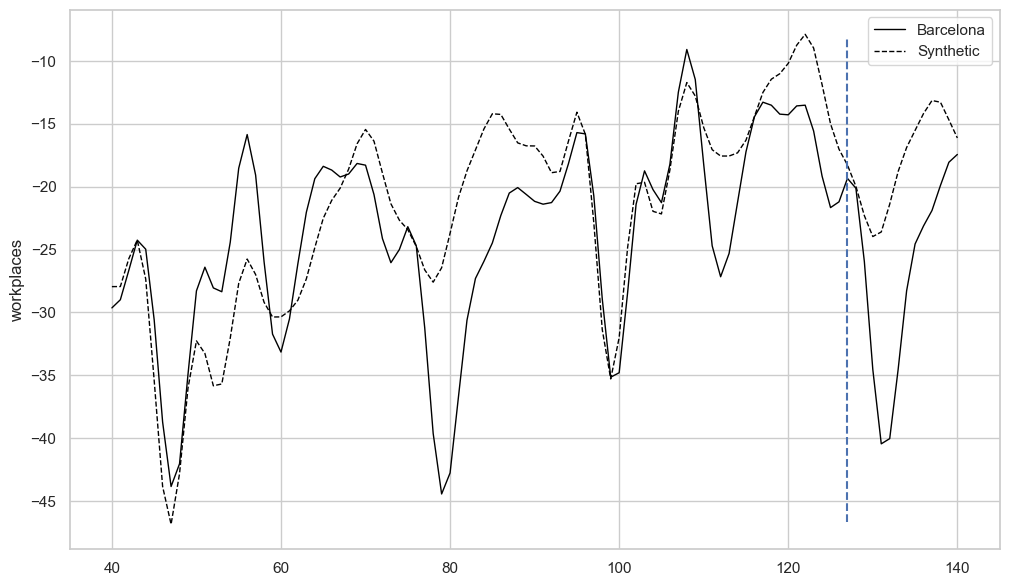


=== STANDARD SCM ===
Pesos significativos:
Berlin    0.495
Messina   0.228
Paris     0.137
Catania   0.085
Palermo   0.025
Napoli    0.022
Genova    0.006
Name: weights, dtype: float64


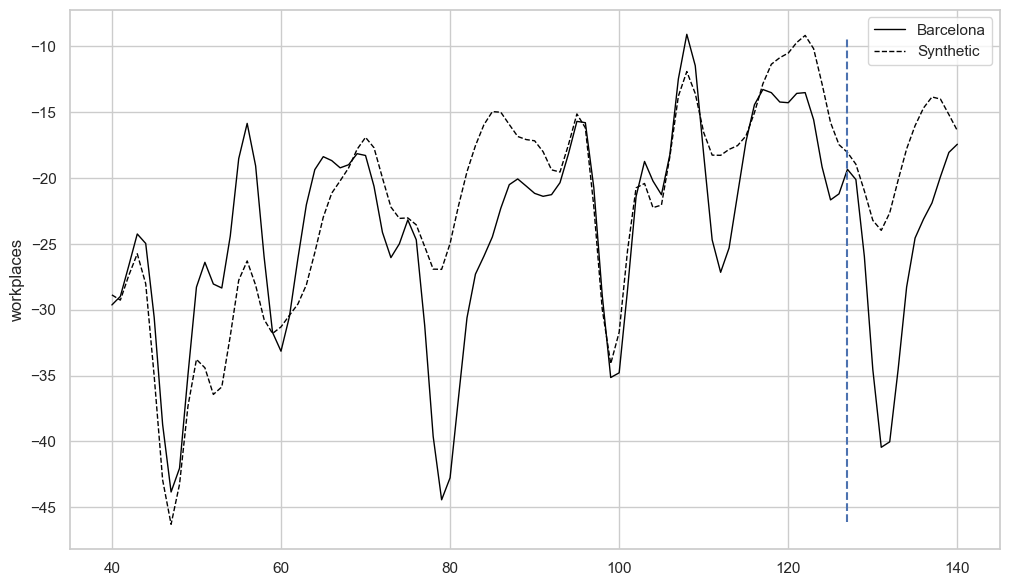

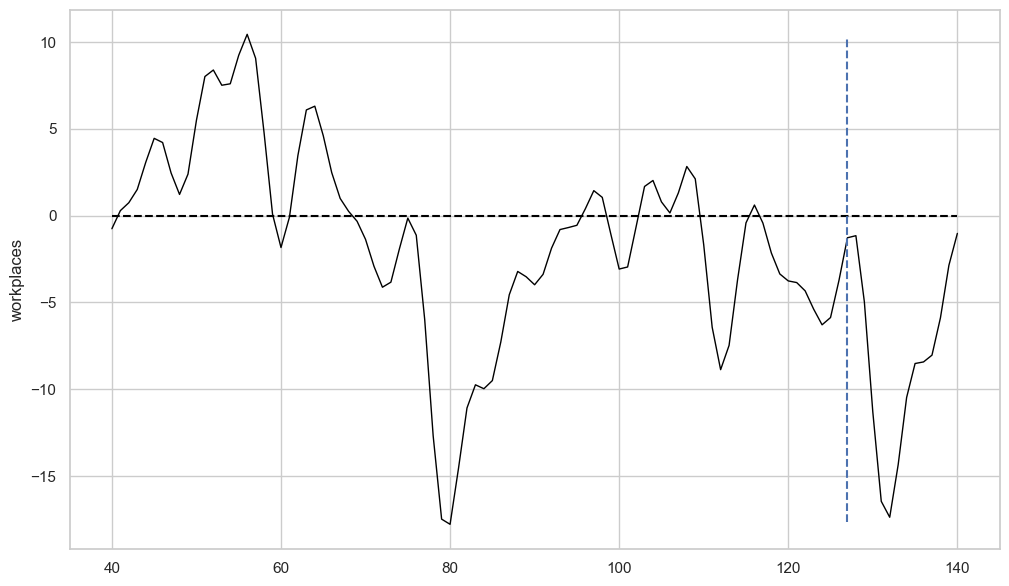


=== AUGMENTED SCM ===
Pesos significativos:
Torino               0.665
Tours                0.600
Roma                 0.518
Firenze              0.515
Stockholm            0.478
München              0.420
Erfurt               0.389
Magdeburg            0.319
Kiel                 0.298
Köln                 0.291
Frankfurt am Main    0.281
Berlin               0.247
Lille                0.242
Strasbourg           0.232
Halle an der Saale   0.224
Marseille            0.207
Lübeck               0.205
Bremen               0.204
Aachen               0.201
Angers               0.179
Messina              0.175
Kassel               0.145
Palermo              0.142
Düsseldorf           0.103
Bochum               0.100
Wuppertal            0.093
Catania              0.091
Essen                0.067
Dortmund             0.067
Mulhouse             0.063
Paris                0.058
Augsburg             0.048
Duisburg             0.039
Bordeaux             0.020
Stuttgart            0.017
Napoli    

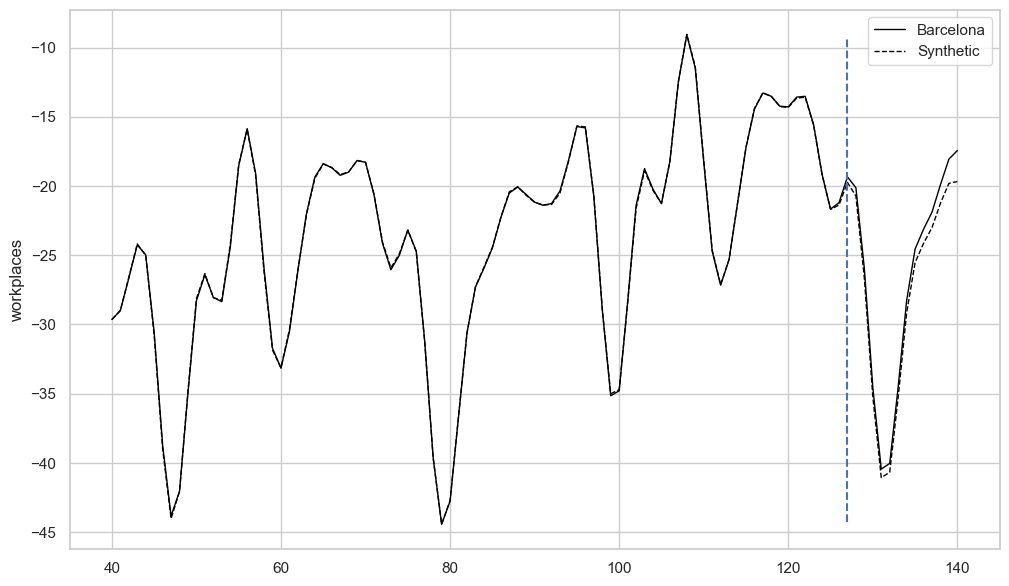

In [218]:
from pysyncon import Dataprep, Synth, AugSynth, PenalizedSynth

# Cargar datos para control sintético
datos_synth = pd.read_csv('../../data/dataset_prueba.csv')
datos_synth['date'] = pd.to_datetime(datos_synth['date'])
datos_synth = datos_synth.sort_values(by=['NAME', 'week']).reset_index(drop=True)

# Definir unidad tratada y controles (excluir ciudades españolas del donor pool)
unidad_tratada = "Barcelona"
ciudades_espanolas = datos_synth[datos_synth['country'] == 'ES']['NAME'].unique().tolist()
ciudades_control = [c for c in datos_synth['NAME'].unique() if c not in ciudades_espanolas]
print(f"Donor pool: {len(ciudades_control)} ciudades no españolas")

# Configurar Dataprep
dataprep = Dataprep(
    foo=datos_synth,
    predictors=[
        "Population", "agriculture", "industry", "construction",
        "age_dependency", "old_age_dependency", "young_age_dependency",
        "sex_ratio", "unemp", "f_unemp",
    ],
    predictors_op="mean",
    time_predictors_prior=range(40, 127),
    special_predictors=[
        ("daily_cases", range(40, 127), "mean"),
    ],
    dependent="workplaces",
    unit_variable="NAME",
    time_variable="week",
    treatment_identifier=unidad_tratada,
    controls_identifier=ciudades_control,
    time_optimize_ssr=range(40, 127),
)

# Modelo 1: Penalized SCM
print("\n=== PENALIZED SCM ===")
pen = PenalizedSynth()
pen.fit(dataprep=dataprep, lambda_=0.01)
print("Pesos significativos:")
print(pen.weights()[pen.weights() > 0.005].sort_values(ascending=False))
pen.path_plot(time_period=range(40, 141), treatment_time=127)

# Modelo 2: Standard SCM
print("\n=== STANDARD SCM ===")
synth = Synth()
synth.fit(dataprep=dataprep, optim_method="Nelder-Mead", optim_initial="ols")
print("Pesos significativos:")
print(synth.weights()[synth.weights() > 0.005].sort_values(ascending=False))
synth.path_plot(time_period=range(40, 141), treatment_time=127)

# Gaps plot
synth.gaps_plot(time_period=range(40, 141), treatment_time=127)

# Modelo 3: Augmented SCM
print("\n=== AUGMENTED SCM ===")
augsynth = AugSynth()
augsynth.fit(dataprep=dataprep)
print("Pesos significativos:")
print(augsynth.weights()[augsynth.weights() > 0.005].sort_values(ascending=False))
augsynth.path_plot(time_period=range(40, 141), treatment_time=127)

In [219]:
synth.summary()


,V,treated,synthetic,sample mean
Population,0.002,3722.424,3384.671,755.627
agriculture,0.001,0.001,0.005,0.005
industry,0.000,0.076,0.119,0.123
construction,0.001,0.056,0.056,0.051
age_dependency,0.451,0.634,0.633,0.660
old_age_dependency,0.207,0.314,0.315,0.322
young_age_dependency,0.329,0.320,0.320,0.340
sex_ratio,0.000,107.033,105.924,106.424
unemp,0.004,15.000,14.624,9.700
f_unemp,0.005,0.142,0.139,0.090


In [220]:
augsynth.summary()

,treated,synthetic,sample mean
Population,3722.424,3707.788,755.627
agriculture,0.001,0.001,0.005
industry,0.076,0.076,0.123
construction,0.056,0.056,0.051
age_dependency,0.634,0.634,0.660
old_age_dependency,0.314,0.314,0.322
young_age_dependency,0.320,0.319,0.340
sex_ratio,107.033,107.038,106.424
unemp,15.000,15.031,9.700
f_unemp,0.142,0.142,0.090


### Conclusiones

Se estimaron tres metodologías complementarias (Penalizado, Estándar y Aumentado) como prueba de robustez.

- Elección del "donor pool": Se excluyeron las ciudades españolas del grupo de donantes porque el "Valor_Stringency_Index" varía a nivel nacional. Todas las ciudades de España experimentaron la misma desescalada en la semana 127, por lo que incluirlas contaminaría el contrafáctico (estarían "tratadas" también). El "donor" pool final contiene 70 ciudades de Alemania, Francia, Italia y Suecia.

#### Calidad del ajuste pre-tratamiento:
- Los modelos Penalized y Standard SCM capturan las tendencias generales de Barcelona, aunque con cierto sesgo de interpolación dado que Barcelona es una ciudad particularmente dinámica y grande.
- El Augmented SCM logra un ajuste superior en el pre-tratamiento al corregir por regresión Ridge el sesgo residual.

#### Efecto causal de la desescalada (post-tratamiento):
- Tras la semana 127, la movilidad real de Barcelona debería incrementarse por encima del control sintético si la flexibilización tuvo efecto causal sobre la movilidad laboral.
- La brecha (gaps plot) permite cuantificar la magnitud del efecto causal semana a semana.
- Eventuales caídas estacionales (agosto) deben interpretarse con cuidado: si ambas series (real y sintética) caen juntas, es un patrón compartido y no invalida el modelo.

#### Conclusión:

Si los tres estimadores coinciden en mostrar una brecha positiva post-tratamiento, esto confirma desde una metodología diferente a los modelos de panel que las restricciones gubernamentales fueron una barrera efectiva sobre la movilidad laboral, y su remoción causó un incremento causal en la presencialidad.